In [1]:
import json
import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import spearmanr, rankdata
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from tqdm.notebook import tqdm
from dateutil.relativedelta import relativedelta


import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

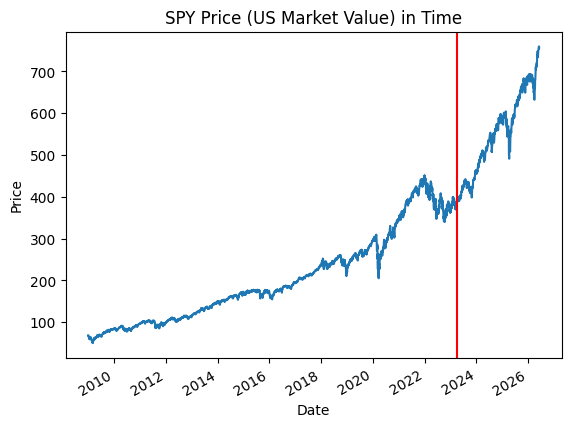

In [2]:
hist = yf.Ticker('SPY').history(start='2009-01-01')
hist['Close'].plot()

plt.title('SPY Price (US Market Value) in Time')
plt.ylabel('Price')
plt.axvline(x = '2023-03-31', color='red')
plt.show()

In [ ]:
def generate_parquets_from_csv(data_dir: str = 'data_quarterly', max_missing_pct: float = 0.2):
    sectors = [f for f in os.listdir(data_dir) if not f.endswith('.json')]
    for sector in tqdm(sectors):
        df = export_csv_for_training(data_dir, [sector], get_metadata=True)

        output_dir = Path(data_dir + '_parquet')
        output_dir.mkdir(parents=True, exist_ok=True)
        df = normalize_schema(df)

        metadata_cols = ['ticker', 'sector', 'industry', 'fiscalDateEnding', 'filing_date_used']
        feature_cols = [c for c in df.columns if c not in metadata_cols]
        mask = df[feature_cols].isnull().mean(axis=1) <= max_missing_pct
        print(f'{sector}: dropping {(~mask).sum()}/{len(df)} rows with >{max_missing_pct:.0%} missing data')
        df = df[mask]

        df.to_parquet(output_dir / f'{sector}.parquet', index=False)
        print(f'Generated data for {sector}')

def normalize_schema(df: pd.DataFrame) -> pd.DataFrame:
    # force datetime columns
    date_cols = ['fiscalDateEnding', 'filing_date_used']
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    # force numeric columns
    for col in df.columns:
        if col not in date_cols:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass

    # force metadata columns
    for col in ['ticker', 'sector', 'industry']:
        if col in df.columns:
            df[col] = df[col].astype('string')

    return df

def export_csv_for_training(
        data_dir: str = 'data_quarterly', 
        sectors: list | None = None,
        get_metadata: bool = False,
    ) -> pd.DataFrame:
    start = time.time()

    if get_metadata:
        with open(os.path.join(data_dir, 'metadata.json')) as f:
            metadata = json.load(f)

    if sectors is None:
        sectors = [f for f in os.listdir(data_dir) if not f.endswith('.json')]

    frames = []

    for sector in sectors:
        sector_path = os.path.join(data_dir, sector)

        for file in os.listdir(sector_path):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(sector_path, file))

            if get_metadata:
                ticker = file[:file.find('.')]
                meta = metadata[ticker]
                meta['ticker'] = ticker

                df_metadata = pd.DataFrame([meta] * len(df), index=df.index)
                df = pd.concat([df, df_metadata], axis=1)
                
            frames.append(df)

    if frames:
        dataset = pd.concat(frames, ignore_index=True)
        dataset['fiscalDateEnding'] = pd.to_datetime(dataset['fiscalDateEnding'])
        print(f"Dataset load time: {(time.time() - start):.2f}s")
        return dataset
    else:
        print("Warnign: No frames found, returning empty DF")
        return pd.DataFrame()

def export_parquets_for_training(
        data_dir: str = 'data_quarterly_parquet',
        sectors: list | None = None,
        get_metadata: bool = False,
        cross_sectional_rank: bool = False,
    ) -> pd.DataFrame:
    start = time.time()

    if sectors is None:
        sectors = [f for f in os.listdir(data_dir)]
    else:
        sectors = [f'{name}.parquet' for name in sectors]

    files = [Path(data_dir) / sector for sector in sectors]
    dataset = pd.read_parquet(files)

    # if not get_metadata:
    #     dataset = dataset.drop(columns=['sector', 'industry', 'ticker'], errors='ignore')

    dataset = pd.read_parquet(files)
    dataset['fiscalDateEnding'] = pd.to_datetime(dataset['fiscalDateEnding'])
    dataset = dataset.sort_values("fiscalDateEnding").reset_index(drop=True)

    # ── Optional Cross-sectional ranking ───────────────────────────────────────────────
    if cross_sectional_rank:
        if 'sector' not in dataset.columns:
            print("Warning: 'sector' column not found — "
                  "cannot rank within sector, skipping cross-sectional ranking. "
                  "Load with get_metadata=True in generate_parquets_from_csv.")
        else:
            dataset = add_cross_sectional_ranks(dataset)

    if not get_metadata:
        dataset = dataset.drop(
            columns=['sector', 'industry', 'ticker'], errors='ignore'
        )

    print(f"Dataset load time: {(time.time() - start):.2f}s")
    return dataset
    

def find_split_date(df: pd.DataFrame, desired_ratio: float = 0.8):
    return df['fiscalDateEnding'].quantile(desired_ratio)

def split_target_with_date_index(df: pd.DataFrame):
    """Like split_target but keeps fiscalDateEnding as index for CV inspection."""
    X = df.drop(columns=["target", "filing_date_used"], errors="ignore")
    X = X.set_index("fiscalDateEnding")
    y = df["target"]
    y.index = X.index
    return X, y

def cleanup_base(X_train, X_test):
    """Always apply — safe for all models"""
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan)

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)
    X_train = X_train.clip(lower=lower, upper=upper, axis=1)
    X_test  = X_test.clip(lower=lower, upper=upper, axis=1)

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_test  = X_test.fillna(medians)

    selector = VarianceThreshold(threshold=1e-5)
    mask = selector.fit(X_train).get_support()
    cols = X_train.columns[mask]
    return X_train[cols], X_test[cols]

def cleanup_linear(X_train, X_test):
    """Apply after cleanup_base for linear models"""
    corr = X_train.corr().abs()
    upper_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper_corr.columns if any(upper_corr[col] > 0.95)]
    X_train = X_train.drop(columns=to_drop)
    X_test  = X_test.drop(columns=to_drop)

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), 
                           columns=X_train.columns, index=X_train.index)
    X_test  = pd.DataFrame(scaler.transform(X_test),
                           columns=X_test.columns, index=X_test.index)
    
    return X_train, X_test


def add_cross_sectional_ranks(df: pd.DataFrame, 
                               group_cols: list = ['fiscalDateEnding', 'sector'],
                               min_group_size: int = 5) -> pd.DataFrame:
    """
    Replace each feature value with its percentile rank within
    the sector x date group. Falls back to date-only ranking
    for groups smaller than min_group_size.
    
    Must be called while sector and fiscalDateEnding are still columns
    (before they are dropped or set as index).
    """
    metadata_cols = ['ticker', 'sector', 'industry', 'fiscalDateEnding', 
                     'filing_date_used', 'target']
    feature_cols  = [c for c in df.columns if c not in metadata_cols]

    print(f"Cross-sectional ranking {len(feature_cols)} features "
          f"across {df['fiscalDateEnding'].nunique()} dates "
          f"x {df['sector'].nunique()} sectors...")

    ranked = df.copy()

    # Precompute group sizes once — reused for every feature
    group_sizes   = df.groupby(group_cols)['sector'].transform('size')
    large_enough  = group_sizes >= min_group_size

    # Warn about thin groups so you know how often fallback fires
    thin_groups = (
        df.groupby(group_cols).size()
        .reset_index(name='n')
        .query('n < @min_group_size')
    )
    if len(thin_groups) > 0:
        print(f"  Warning: {len(thin_groups)} sector x date groups have "
              f"< {min_group_size} stocks — using date-only rank as fallback")
        print(f"  Smallest groups:\n{thin_groups.nsmallest(5, 'n').to_string(index=False)}")

    for col in tqdm(feature_cols, desc="  Ranking features", leave=False):
        sector_date_rank = df.groupby(group_cols)[col].rank(
            pct=True, na_option='keep'
        )
        date_only_rank = df.groupby('fiscalDateEnding')[col].rank(
            pct=True, na_option='keep'
        )
        ranked[col] = np.where(large_enough, sector_date_rank, date_only_rank)

    return ranked

def rank_target_globally(y: pd.Series) -> pd.Series:
    """
    Global percentile rank across the entire training window.
    Use for feature selection and model training — NOT per-date.
    """
    return pd.Series(rankdata(y) / len(y), index=y.index, name=y.name)

def rank_target_cross_sectionally(y: pd.Series) -> pd.Series:
    """
    Rank target within each fiscal quarter (date bin).
    Each stock gets a 0->1 rank relative to peers reporting
    in the same quarter. Leak-free by construction.
    
    y must have a fiscalDateEnding DatetimeIndex.
    """
    bins = pd.PeriodIndex(y.index, freq='Q').asi8
    ranked = y.copy().astype(float)
    for b in np.unique(bins):
        mask = bins == b
        if mask.sum() < 2:
            continue
        ranked.iloc[mask] = rankdata(y.iloc[mask]) / mask.sum()
    return ranked

In [4]:
# ─── Config additions ─────────────────────────────────────────────────────────
USE_GPU        = True   # set False to fall back to CPU
DEVICE         = "cuda" if USE_GPU else "cpu"

# ─── GPU check ────────────────────────────────────────────────────────────────
def check_gpu():
    try:
        import subprocess
        result = subprocess.run(
            ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
            capture_output=True, text=True, timeout=5
        )
        if result.returncode == 0:
            print(f"GPU detected: {result.stdout.strip()}")
            return True
    except Exception:
        pass
    print("No GPU detected — falling back to CPU")
    return False

if USE_GPU:
    USE_GPU = check_gpu()
    DEVICE  = "cuda" if USE_GPU else "cpu"

GPU detected: NVIDIA GeForce GTX 1070, 8192 MiB


In [ ]:
# ─── Config ───────────────────────────────────────────────────────────────────
N_TRIALS_SHORT = 30
N_TRIALS_FULL  = 150
TOP_K          = 100
N_FOLDS        = 3       # for TimeSeriesSplit
TRAIN_RATIO    = 0.7     # 70% train | 15% val | 15% test (approximate)
VAL_RATIO      = 0.85
RANDOM_STATE   = 42
ALPHA_WEIGHT   = 0.5
BETA_WEIGHT    = 0.5

In [ ]:
# ─── 2. Cleanup — fit on train, apply to val and test ─────────────────────────
def cleanup_base_three_way(X_train, X_val, X_test):
    """Fit on train, apply to val and test"""
    for df_ in [X_train, X_val, X_test]:
        df_.replace([np.inf, -np.inf], np.nan, inplace=True)

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)
    X_train = X_train.clip(lower=lower, upper=upper, axis=1)
    X_val   = X_val.clip(lower=lower, upper=upper, axis=1)
    X_test  = X_test.clip(lower=lower, upper=upper, axis=1)

    medians = X_train.median()
    X_train = X_train.fillna(medians)
    X_val   = X_val.fillna(medians)
    X_test  = X_test.fillna(medians)

    selector = VarianceThreshold(threshold=1e-5)
    selector.fit(X_train)
    cols = X_train.columns[selector.get_support()]
    return X_train[cols], X_val[cols], X_test[cols]

In [ ]:
# ─── Feature selection methods ─────────────────────────────────────────────
def method_shap(X_tr, y_tr, base_reg, top_k=TOP_K):
    model = clone(base_reg).fit(X_tr, y_tr)
    sv    = shap.TreeExplainer(model).shap_values(X_tr)
    idx   = np.argsort(np.abs(sv).mean(axis=0))[-top_k:]
    return X_tr.columns[idx].tolist()

def method_rfe(X_tr, y_tr, base_reg, top_k=TOP_K):
    rfe = RFE(clone(base_reg), n_features_to_select=top_k, step=50, verbose=0)
    rfe.fit(X_tr, y_tr)
    return X_tr.columns[rfe.support_].tolist()

def _ic_scorer(estimator, X, y):
    preds = estimator.predict(X)
    ic, _ = spearmanr(y, preds)
    return ic if not np.isnan(ic) else 0.0

def method_permutation(X_tr, y_tr, base_reg, top_k=TOP_K, n_repeats=5):
    model = clone(base_reg).fit(X_tr, y_tr)
    res   = permutation_importance(
        model, X_tr, y_tr, n_repeats=n_repeats,
        random_state=RANDOM_STATE, scoring=_ic_scorer,
    )
    idx = np.argsort(res.importances_mean)[-top_k:]
    return X_tr.columns[idx].tolist()

GAP_DAYS = 456  # 12-month return horizon + 3-month filing buffer (≥ 365+91)
QUARTER_DAYS = 91  # ~3 months per val slice

def _assign_quarter_bins(dates: pd.DatetimeIndex) -> np.ndarray:
    """
    Use pandas Q periods so Mar-31, Apr-1, Apr-2 all land in the same
    calendar quarter. Robust to anchor outliers and shifted reporters.
    """
    periods = pd.PeriodIndex(dates, freq='Q')
    return periods.asi8 

def quick_cv_ic_gapped(
    feats: list[str],
    X_tr: pd.DataFrame,       # index = fiscalDateEnding
    y_tr: pd.Series,
    base_reg,
    gap_days: int = GAP_DAYS,
    train_years: int = 5,
    val_quarters: int = 4,
) -> tuple[float, float, float]:
    """
    Walk-forward IC CV with fixed-width training window and explicit gap.

    Dates are binned into rolling ~91-day (quarter) windows anchored at the
    earliest date in the dataset.  This ensures stocks with shifted fiscal
    quarter-ends (e.g. Mar-28 vs Mar-31) land in the same quarterly bucket
    rather than being split across fold boundaries.

    Val slices tile the entire usable date range with no overlaps.
    Fold 1 train starts at the earliest date; last fold val ends at the latest.
    Returns (mean_ic, std_ic, mean_rmse) — higher mean_ic is better.
    """
    dates = X_tr.index.sort_values().unique()

    # ── bin every date into a quarter index ──────────────────────────────────
    bin_index = _assign_quarter_bins(dates)
    # map date -> bin for fast lookup later
    date_to_bin = dict(zip(dates, bin_index))

    # unique bins in chronological order
    unique_bins  = np.unique(bin_index)
    # representative "start date" of each bin (earliest date that falls in it)
    bin_start: dict[int, pd.Timestamp] = {}
    bin_end:   dict[int, pd.Timestamp] = {}
    for d, b in zip(dates, bin_index):
        if b not in bin_start or d < bin_start[b]:
            bin_start[b] = d
        if b not in bin_end or d > bin_end[b]:
            bin_end[b] = d

    # ── find which bins are eligible as val windows ───────────────────────────
    first_val_start_date = dates[0] + pd.DateOffset(years=train_years) \
                                     + pd.Timedelta(days=gap_days)

    val_bins = unique_bins[
        np.array([bin_start[b] for b in unique_bins]) >= first_val_start_date
    ]

    if len(val_bins) == 0:
        print("[ERROR] No valid val bins found — dataset too short for given train_years + gap_days")
        return 0.0, 0.0, 0.0
    
    grouped = [val_bins[i:i+val_quarters]
               for i in range(0, len(val_bins) - val_quarters + 1, val_quarters)]

    print(f"[INFO] {len(grouped)} val folds x {val_quarters}Q each, "
          f"derived from {len(val_bins)} eligible bins "
          f"({bin_start[val_bins[0]].strftime('%Y-%m-%d')} → "
          f"{bin_end[val_bins[-1]].strftime('%Y-%m-%d')})")

    fold_ics   = []
    fold_rmses = []

    for i, bin_group in enumerate(grouped):
        # all dates whose bin falls in this fold's val window
        val_dates  = dates[np.isin(bin_index, bin_group)]
        val_cutoff = val_dates.min()

        # training window: fixed-width before (val_cutoff - gap)
        train_cutoff = val_cutoff - pd.Timedelta(days=gap_days)
        train_start  = train_cutoff - pd.DateOffset(years=train_years)
        train_dates  = dates[(dates >= train_start) & (dates < train_cutoff)]

        # if len(train_dates) < 50:
        #     print(f"[WARN] bin {val_bin} ({val_cutoff.strftime('%Y-%m-%d')}): "
        #           f"train={len(train_dates)} (min 50) — skipping")
        #     continue
        # if len(val_dates) < 3:   # ← lowered; 1 quarter in a single sector won't have 10 unique dates
        #     print(f"[WARN] bin {val_bin} ({val_cutoff.strftime('%Y-%m-%d')}): "
        #           f"val={len(val_dates)} (min 3) — skipping")
        #     continue

        mask_tr  = X_tr.index.isin(train_dates)
        mask_val = X_tr.index.isin(val_dates)

        # require enough *rows* (stocks), not just unique dates
        # if mask_tr.sum() < 50 or mask_val.sum() < 5:
        #     print(f"[WARN] bin {val_bin}: "
        #           f"n_train_rows={mask_tr.sum()} (min 50), "
        #           f"n_val_rows={mask_val.sum()} (min 5) — skipping")
        #     continue

        if mask_tr.sum() < 50 or mask_val.sum() < 5:
            print(f"[WARN] fold {i+1}: n_train={mask_tr.sum()} n_val={mask_val.sum()} — skipping")
            continue

        fold_X_tr  = X_tr.loc[mask_tr,  feats]
        fold_y_tr  = y_tr.loc[mask_tr]
        fold_X_val = X_tr.loc[mask_val, feats]
        fold_y_val = y_tr.loc[mask_val]

        m     = clone(base_reg).fit(fold_X_tr, fold_y_tr)
        preds = pd.Series(m.predict(fold_X_val), index=fold_y_val.index)

        # ── per-bin IC (one IC per quarter bucket, not per exact date) ────────
        # val_row_bins = np.array([date_to_bin[d] for d in fold_y_val.index])
        ic, _ = spearmanr(fold_y_val.values, preds.values)
        
        if np.isnan(ic):
            print(f"[WARN] fold {i+1}: IC is NaN — skipping")
            continue

        fold_ics.append(ic)
        fold_rmses.append(float(np.sqrt(np.mean((fold_y_val.values - preds.values) ** 2))))

        q_label = " + ".join(
            str(pd.Period(ordinal=int(b), freq='Q')) for b in bin_group
        )
        
        print(f"    fold {i+1:2d} [{q_label}] "
              f"val {val_cutoff.strftime('%Y-%m-%d')} → {val_dates.max().strftime('%Y-%m-%d')} "
              f"| train {train_dates[0].strftime('%Y-%m-%d')} → {train_cutoff.strftime('%Y-%m-%d')} "
              f"| n_train={mask_tr.sum():5d} n_val={mask_val.sum():4d} "
              f"| IC={fold_ics[-1]:.4f} RMSE={fold_rmses[-1]:.4f}")
        
    if not fold_ics:
        return 0.0, 0.0, 0.0

    mean_ic, std_ic, mean_rmse = np.mean(fold_ics), np.std(fold_ics), np.mean(fold_rmses)
    print(f"\n[RESULT] {len(fold_ics)} folds | "
          f"IC={mean_ic:.4f} ± {std_ic:.4f} | RMSE={mean_rmse:.4f}")
    return mean_ic, std_ic, mean_rmse



In [ ]:
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

def load_or_run_feature_selection(X_train, y_reg_train, base_reg, 
                                   force: bool = False, 
                                   experiment_name: str = ""):
    cache_name = "feature_selection" 
    if experiment_name != "":
        cache_name += f"_{experiment_name}"
    cache_file = CACHE_DIR / f"{cache_name}.json"
    print(f"Cache file: {cache_file}")

    method_fns = {
        "shap":        lambda: method_shap(X_train, y_reg_train, base_reg),
        "rfe":         lambda: method_rfe(X_train, y_reg_train, base_reg),
        "permutation": lambda: method_permutation(X_train, y_reg_train, base_reg),
    }

    cached = {}
    if not force and cache_file.exists(): 
        with open(cache_file) as f:
            cached = json.load(f)
        if cached:
            print("Loaded from cache:")
            for method_name, feats in cached.items():   # ← method_name
                print(f"  {method_name:12s} -> {len(feats)} features")

    pending = {method_name: fn 
               for method_name, fn in method_fns.items() 
               if method_name not in cached}

    if not pending:
        print("All methods already cached, nothing to run.")
        return cached

    print(f"Running {len(pending)}/{len(method_fns)} method(s): {', '.join(pending)}")
    methods = dict(cached)
    total_start = time.time()

    with tqdm(total=len(pending), desc="Feature selection", unit="method") as pbar:
        completed_times = []

        for method_name, fn in pending.items():  
            pbar.set_postfix_str(f"running {method_name}...")
            t0 = time.time()

            feats = fn()
            elapsed = time.time() - t0
            methods[method_name] = feats
            completed_times.append(elapsed)

            with open(cache_file, "w") as f:
                json.dump(methods, f, indent=2)

            avg_time  = sum(completed_times) / len(completed_times)
            remaining = len(pending) - len(completed_times)
            eta       = avg_time * remaining

            pbar.set_postfix_str(
                f"{method_name} done — {len(feats)} feats, "
                f"took {elapsed:.0f}s, "
                f"ETA {eta:.0f}s"
            )
            pbar.update(1)

    total_elapsed = time.time() - total_start
    print(f"\nFeature selection complete in {total_elapsed:.0f}s")
    print(f"  {'method':<12}  {'features':>8}  {'time':>8}")
    print(f"  {'-'*12}  {'-'*8}  {'-'*8}")
    for (method_name, feats), t in zip(
        {n: methods[n] for n in pending}.items(),
        completed_times
    ):
        print(f"  {method_name:<12}  {len(feats):>8}  {t:>7.1f}s")

    print(f"\nSaved to {cache_file}")
    return methods

In [ ]:
# ─── 6. Scorecard ─────────────────────────────────────────────────────────────
def compute_scorecard(reg_model, X, y_reg, split_name="val"):
    reg_preds = reg_model.predict(X)

    # Period-by-period IC for ICIR
    preds_s = pd.Series(reg_preds, index=y_reg.index)
    bins = pd.PeriodIndex(y_reg.index, freq='Q').asi8

    period_ics = []
    for b in np.unique(bins):
        mask = bins == b
        if mask.sum() < 5:
            continue
        ic, _ = spearmanr(y_reg.values[mask], preds_s.values[mask])
        if not np.isnan(ic):
            period_ics.append(ic)

    mean_ic = float(np.mean(period_ics)) if period_ics else 0.0
    std_ic  = float(np.std(period_ics))  if period_ics else 0.0
    icir    = mean_ic / std_ic if std_ic > 0 else 0.0

    # Global IC (for reference)
    global_ic, _ = spearmanr(y_reg, reg_preds)

    return {
        f"{split_name}_ic":      mean_ic,    # mean period IC — primary metric
        f"{split_name}_icir":    icir,        # IC / std(IC) — consistency
        f"{split_name}_ic_std":  std_ic,      # period IC volatility
        f"{split_name}_ic_global": global_ic, # overall IC (secondary)
        f"{split_name}_rmse":    root_mean_squared_error(y_reg, reg_preds),
        f"{split_name}_r2":      r2_score(y_reg, reg_preds),
        # f"{split_name}_dir_acc": (np.sign(reg_preds) == np.sign(y_reg.values)).mean(),
        # f"{split_name}_auc":     roc_auc_score(y_clf, clf_proba),
        # f"{split_name}_acc":     accuracy_score(y_clf, clf_preds),
        # f"{split_name}_mcc":     matthews_corrcoef(y_clf, clf_preds),
        # f"{split_name}_logloss": log_loss(y_clf, clf_proba),
    }

# ─── 7. Optuna objective factory ──────────────────────────────────────────────
def make_objective(features, X_train, y_train, gap_days=GAP_DAYS):

    def objective(trial):
        params = dict(
            n_estimators      = trial.suggest_int("n_estimators", 100, 1000),
            max_depth         = trial.suggest_int("max_depth", 3, 10),
            learning_rate     = trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
            subsample         = trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
            colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
            min_child_weight  = trial.suggest_int("min_child_weight", 1, 20),
            reg_alpha         = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            reg_lambda        = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            gamma             = trial.suggest_float("gamma", 0.0, 5.0),
            tree_method       = "hist",
            device            = DEVICE,
            random_state      = RANDOM_STATE,
            verbosity         = 0,
        )

        trial_reg = xgb.XGBRegressor(**params)
        mean_ic, std_ic, mean_rmse = quick_cv_ic_gapped(
            features, X_train, y_train,
            base_reg=trial_reg,
            gap_days=gap_days,
        )

        icir = mean_ic / std_ic if std_ic > 0 else 0.0
        trial.set_user_attr("val_ic",   mean_ic)
        trial.set_user_attr("val_icir", icir)
        trial.set_user_attr("val_ic_std", std_ic)
        trial.set_user_attr("val_rmse", mean_rmse)

        return -mean_ic   # Optuna minimises

    return objective


In [ ]:
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def _model_paths(experiment_name: str = ""):
    """Generate clean file paths — scores never go in the filename."""
    prefix = f"final_{experiment_name}" if experiment_name else "final"
    return (
        RESULTS_DIR / f"{prefix}_reg.ubj",
        RESULTS_DIR / f"{prefix}_clf.ubj",
        RESULTS_DIR / f"{prefix}_meta.json",
    )

def save_final_models(reg_model, clf_model, best_method, best_feats, scores, best_params,
                      experiment_name: str = ""):
    RESULTS_DIR.mkdir(exist_ok=True)
    reg_path, clf_path, meta_path = _model_paths(experiment_name)

    reg_model.save_model(reg_path)
    if clf_model is not None:
        clf_model.save_model(clf_path)

    # numpy scalars aren't JSON-serialisable — convert everything to plain Python
    def _clean(v):
        if hasattr(v, "item"):      
            return v.item()
        return v

    meta = {
        "best_method": best_method,
        "best_feats":  best_feats,
        "best_params": {k: _clean(v) for k, v in best_params.items()},
        "scores":      {k: _clean(v) for k, v in scores.items()},
    }

    with open(meta_path, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Models saved → {reg_path.name}, {clf_path.name}, {meta_path.name}")

def load_final_models(study_name: str = ""):
    reg_path, clf_path, meta_path = _model_paths(study_name)

    if not all(p.exists() for p in [reg_path, clf_path, meta_path]):
        label = f" [{study_name}]" if study_name else ""
        print(f"No saved models found{label}, will train from scratch.")
        return None, None, None

    reg_model = xgb.XGBRegressor()
    reg_model.load_model(reg_path)

    clf_model = xgb.XGBClassifier()
    clf_model.load_model(clf_path)

    with open(meta_path) as f:
        meta = json.load(f)

    label = f" [{study_name}]" if study_name else ""
    print(f"Loaded existing final models{label} (method={meta['best_method']})")
    return reg_model, clf_model, meta

In [ ]:
def training_pipeline(
        df: pd.DataFrame,
        optuna_storage_name: str,
        force_feature_selection: bool = False,
        experiment_name: str = ""):

    print("\n─── Load & Clean Data ────────────────────────────────────")

    TEST_MONTHS = 24

    GAP        = pd.Timedelta(days=GAP_DAYS)
    data_end   = df['fiscalDateEnding'].max()

    # 2-way split: train pool | GAP | test
    test_end = data_end
    test_start = data_end - pd.DateOffset(months=TEST_MONTHS)
    train_cutoff = test_start - GAP # everything up to here is in the train pool

    print(f"Train pool : up to  {train_cutoff.strftime('%Y-%m-%d')}")
    print(f"Gap        : {GAP.days}d -> {test_start.strftime('%Y-%m-%d')}")
    print(f"Test        : {test_start.strftime('%Y-%m-%d')} -> {test_end.strftime('%Y-%m-%d')}")

    print(f"Train rows : {(df.fiscalDateEnding <= train_cutoff).sum()}")
    print(f"Test rows : {((df.fiscalDateEnding >= test_start) & (df.fiscalDateEnding <= test_end)).sum()}")
    print(f"Train dates : {df.loc[df.fiscalDateEnding <= train_cutoff, 'fiscalDateEnding'].nunique()}")
    print(f"Test dates : {df.loc[(df.fiscalDateEnding >= test_start) & (df.fiscalDateEnding <= test_end), 'fiscalDateEnding'].nunique()}")

    train_df = df[df['fiscalDateEnding'] <= train_cutoff].copy()
    test_df  = df[(df['fiscalDateEnding'] >= test_start) &
                  (df['fiscalDateEnding'] <= test_end)].copy()

    X_train_raw, y_reg_train_raw = split_target_with_date_index(train_df)
    X_test_raw,  y_reg_test_raw  = split_target_with_date_index(test_df)

    # ── Rank-transform targets ────────────────────────────────────────────────────
    # Fit rank on train only; val/test ranked independently so no leakage.
    y_reg_train = rank_target_cross_sectionally(y_reg_train_raw)
    y_reg_test  = rank_target_cross_sectionally(y_reg_test_raw)

    print(f"\nSplit sizes → train: {len(X_train_raw):,} test: {len(X_test_raw):,}")

    X_train, X_test = cleanup_base(X_train_raw, X_test_raw)
    print(f"Features after variance threshold: {X_train.shape[1]}")

    base_reg = xgb.XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        tree_method="hist", device=DEVICE,
        random_state=RANDOM_STATE, verbosity=0,
    )

    # ── Feature selection ─────────────────────────────────────────────────────
    print("\n─── Feature selection ────────────────────────────────────")
    methods = load_or_run_feature_selection(
        X_train, y_reg_train, base_reg,
        force_feature_selection, experiment_name
    )

    # Evaluate each method by IC
    print(f"\n  {'method':<12}  {'n_feats':>7}  {'mean_IC':>8}  {'std_IC':>7}  {'ICIR':>6}  {'RMSE':>7}")
    print(f"  {'-'*12}  {'-'*7}  {'-'*8}  {'-'*7}  {'-'*6}  {'-'*7}")
    for name, feats in methods.items():
        mean_ic, std_ic, mean_rmse = quick_cv_ic_gapped(feats, X_train, y_reg_train, base_reg)
        icir = mean_ic / std_ic if std_ic > 0 else 0.0
        print(f"  {name:<12}  {len(feats):>7}  {mean_ic:>8.4f}  "
              f"{std_ic:>7.4f}  {icir:>6.3f}  {mean_rmse:>7.4f}")

    # ── Optuna ────────────────────────────────────────────────────────────────
    print("\n─── Preliminary Optuna pass ──────────────────────────────")
    preliminary  = {}

    for name, feats in tqdm(methods.items(), desc="Methods", unit="method", position=0):
        study_name = f"{experiment_name}_short_{name}"
        study = optuna.create_study(
            direction="minimize",
            study_name=study_name,
            storage=optuna_storage_name,
            load_if_exists=True,
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
            pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
        )

        remaining = N_TRIALS_SHORT - len(study.trials)
        if remaining <= 0:
            print(f"\n  {name}: already complete ({len(study.trials)} trials), skipping")
            preliminary[name] = study
            continue

        with tqdm(total=remaining, desc=f"  {name}", unit="trial",
                  position=1, leave=False) as trial_bar:

            def callback(study, trial):
                trial_bar.set_postfix_str(
                    f"best={study.best_value:.4f}  "
                    f"IC={trial.user_attrs.get('val_ic', float('nan')):.4f}  "
                    f"RMSE={trial.user_attrs.get('val_rmse', float('nan')):.4f}"
                )
                trial_bar.update(1)

            study.optimize(
                make_objective(feats, X_train, y_reg_train),
                n_trials=remaining,
                callbacks=[callback],
                show_progress_bar=False,
            )

        preliminary[name] = study
        t = study.best_trial
        print(f"  {name:<12}  combined={study.best_value:.4f}"
              f"  IC={t.user_attrs['val_ic']:.4f}"
              f"  RMSE={t.user_attrs['val_rmse']:.4f}")

    # ── Full pass on winner ───────────────────────────────────────────────────
    best_method = min(preliminary, key=lambda k: preliminary[k].best_value)
    best_feats  = methods[best_method]
    final_name  = f"{experiment_name}_final_{best_method}"

    print(f"\n─── Full Optuna pass → winner: {best_method} "
          f"({len(best_feats)} features) ────")

    final_study = optuna.create_study(
        direction="minimize",
        study_name=final_name,
        storage=optuna_storage_name,
        load_if_exists=True,
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
    )

    # Seed with preliminary trials if brand new
    if len(final_study.trials) == 0:
        for trial in preliminary[best_method].trials:
            final_study.add_trial(trial)
        print(f"  Seeded with {len(preliminary[best_method].trials)} preliminary trials")
    else:
        print(f"  Resuming — {len(final_study.trials)} trials already done")

    remaining = N_TRIALS_FULL - len(final_study.trials)
    if remaining > 0:
        with tqdm(total=remaining, desc="  final", unit="trial") as trial_bar:

            def final_callback(study, trial):
                trial_bar.set_postfix_str(
                    f"best={study.best_value:.4f}  "
                    f"IC={trial.user_attrs.get('val_ic', float('nan')):.4f}  "
                    f"RMSE={trial.user_attrs.get('val_rmse', float('nan')):.4f}"
                )
                trial_bar.update(1)

            final_study.optimize(
                make_objective(best_feats, X_train, y_reg_train),
                n_trials=remaining,
                callbacks=[final_callback],
                show_progress_bar=False,
            )
    else:
        print(f"  Already complete ({len(final_study.trials)} trials)")

    t = final_study.best_trial
    print(f"\nBest combined : {final_study.best_value:.4f}")
    print(f"  val IC      : {t.user_attrs['val_ic']:.4f}")
    print(f"  val RMSE    : {t.user_attrs['val_rmse']:.4f}")

    # Verify the gap is respected
    assert X_train.index.max() <= train_cutoff, \
        f"Trainval bleeds into test gap: {X_train.index.max().date()} > {train_cutoff.date()}"
    
    best_params = final_study.best_params
    final_reg   = xgb.XGBRegressor(
        **best_params, tree_method="hist", device=DEVICE,
        random_state=RANDOM_STATE, verbosity=0,
    )
    final_reg.fit(X_train[best_feats], y_reg_train)

    scores = compute_scorecard(
        final_reg,
        X_test[best_feats], y_reg_test,
        split_name="test",
    )

    print("\n─── Test set results ─────────────────────────────────────")
    print(f"  Feature method : {best_method}  ({len(best_feats)} features)")
    print(f"\n  Regression (ranking quality)")
    print(f"    Mean period IC : {scores['test_ic']:.4f}   "
          f"← primary metric, target >0.05")
    print(f"    ICIR           : {scores['test_icir']:.4f}   "
          f"← consistency, target >0.5")
    print(f"    IC std         : {scores['test_ic_std']:.4f}   "
          f"← lower = more stable")
    # print(f"    Direction acc  : {scores['test_dir_acc']:.4f}")
    print(f"    RMSE           : {scores['test_rmse']:.4f}   ← secondary")
    print(f"    R²             : {scores['test_r2']:.4f}")
    # print(f"\n  Classification (beat market?)")
    # print(f"    AUC            : {scores['test_auc']:.4f}")
    # print(f"    Accuracy       : {scores['test_acc']:.4f}")
    # print(f"    MCC            : {scores['test_mcc']:.4f}")
    # print(f"    Log loss       : {scores['test_logloss']:.4f}")

    save_final_models(
        reg_model=final_reg,
        clf_model=None,
        best_method=best_method,
        best_feats=best_feats,
        scores=scores,
        best_params=best_params,
        experiment_name=experiment_name,         
    )

    return scores, final_reg, best_feats

In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
import shap
import json
from pathlib import Path

from tqdm import tqdm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    root_mean_squared_error, mean_squared_error, r2_score,
    roc_auc_score, accuracy_score,
    matthews_corrcoef, log_loss,
)
from sklearn.base import clone
from scipy.stats import spearmanr
from concurrent.futures import ThreadPoolExecutor

optuna.logging.set_verbosity(optuna.logging.WARNING)

STUDY_STORAGE = "sqlite:///optuna_studies.db"

# TO RUN:
df = export_parquets_for_training(cross_sectional_rank=False, sectors=["healthcare"])
scores, final_reg, best_feats = training_pipeline(df, STUDY_STORAGE, False, "healthcare_ic")
 

Dataset load time: 0.69s

─── Load & Clean Data ────────────────────────────────────
Train pool : up to  2021-12-30
Gap        : 456d -> 2023-03-31
Test        : 2023-03-31 -> 2025-03-31
Train rows : 13668
Test rows : 5678
Train dates : 119
Test dates : 25

Split sizes → train: 13,668 test: 5,678
Features after variance threshold: 610

─── Feature selection ────────────────────────────────────
Cache file: cache/feature_selection_healthcare_ic.json
Running 3/3 method(s): shap, rfe, permutation


Feature selection: 100%|██████████| 3/3 [10:32<00:00, 210.78s/method, permutation done — 100 feats, took 595s, ETA 0s]



Feature selection complete in 632s
  method        features      time
  ------------  --------  --------
  shap               100      3.5s
  rfe                100     33.7s
  permutation        100    595.1s

Saved to cache/feature_selection_healthcare_ic.json

  method        n_feats   mean_IC   std_IC    ICIR     RMSE
  ------------  -------  --------  -------  ------  -------
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train= 5640 n_val=1654 | IC=0.3054 RMSE=0.2740
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train= 6104 n_val=1780 | IC=0.1265 RMSE=0.2999
    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 6662 n_val=1952 | IC=0.4275 RMSE=0.2599

[RESULT] 3 folds | IC=0.2865 ± 0.1236 | RMSE=0.2779

Methods:   0%|          | 0/3 [00:00<?, ?method/s]

[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train= 5640 n_val=1654 | IC=0.3418 RMSE=0.2673
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train= 6104 n_val=1780 | IC=0.1058 RMSE=0.2874


...

  final:  99%|█████████▉| 119/120 [52:00<00:21, 21.05s/trial, best=-0.3212  IC=0.3088  RMSE=0.2752]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 6662 n_val=1952 | IC=0.4708 RMSE=0.2690

[RESULT] 3 folds | IC=0.3088 ± 0.1489 | RMSE=0.2752
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train= 5640 n_val=1654 | IC=0.3508 RMSE=0.2698
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train= 6104 n_val=1780 | IC=0.1241 RMSE=0.2841


  final: 100%|██████████| 120/120 [52:21<00:00, 26.18s/trial, best=-0.3212  IC=0.3175  RMSE=0.2727]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 6662 n_val=1952 | IC=0.4774 RMSE=0.2641

[RESULT] 3 folds | IC=0.3175 ± 0.1461 | RMSE=0.2727

Best combined : -0.3212
  val IC      : 0.3212
  val RMSE    : 0.2722



─── Test set results ─────────────────────────────────────
  Feature method : rfe  (100 features)

  Regression (ranking quality)
    Mean period IC : 0.3406   ← primary metric, target >0.05
    ICIR           : 4.9889   ← consistency, target >0.5
    IC std         : 0.0683   ← lower = more stable
    RMSE           : 0.2724   ← secondary
    R²             : 0.1093
Models saved → final_healthcare_ic_reg.ubj, final_healthcare_ic_clf.ubj, final_healthcare_ic_meta.json


In [18]:
df = export_parquets_for_training(cross_sectional_rank=False, sectors=["industrials"])
scores, final_reg, best_feats = training_pipeline(df, STUDY_STORAGE, True, "industrials_ic")

Dataset load time: 0.30s

─── Load & Clean Data ────────────────────────────────────
Train pool : up to  2021-12-30
Gap        : 456d -> 2023-03-31
Test        : 2023-03-31 -> 2025-03-31
Train rows : 14719
Test rows : 3764
Train dates : 119
Test dates : 25

Split sizes → train: 14,719 test: 3,764
Features after variance threshold: 610

─── Feature selection ────────────────────────────────────
Cache file: cache/feature_selection_industrials_ic.json
Running 3/3 method(s): shap, rfe, permutation


Feature selection: 100%|██████████| 3/3 [11:28<00:00, 229.59s/method, permutation done — 100 feats, took 651s, ETA 0s]



Feature selection complete in 689s
  method        features      time
  ------------  --------  --------
  shap               100      7.9s
  rfe                100     29.4s
  permutation        100    651.4s

Saved to cache/feature_selection_industrials_ic.json

  method        n_feats   mean_IC   std_IC    ICIR     RMSE
  ------------  -------  --------  -------  ------  -------
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train= 7145 n_val=1581 | IC=0.1308 RMSE=0.2902
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train= 7328 n_val=1606 | IC=0.0599 RMSE=0.3020
    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 7504 n_val=1657 | IC=0.1266 RMSE=0.2938

[RESULT] 3 folds | IC=0.1058 ± 0.0325 | RMSE=0.295

Methods: 100%|██████████| 3/3 [00:00<00:00, 17.71method/s]


  shap: already complete (30 trials), skipping

  rfe: already complete (30 trials), skipping

  permutation: already complete (30 trials), skipping

─── Full Optuna pass → winner: shap (100 features) ────


...

  final:  99%|█████████▉| 110/111 [48:51<00:11, 11.13s/trial, best=-0.1321  IC=0.1134  RMSE=0.2902]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 7504 n_val=1657 | IC=0.1638 RMSE=0.2853

[RESULT] 3 folds | IC=0.1134 ± 0.0567 | RMSE=0.2902
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train= 7145 n_val=1581 | IC=0.1669 RMSE=0.2829
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train= 7328 n_val=1606 | IC=0.0065 RMSE=0.3003


  final: 100%|██████████| 111/111 [48:56<00:00, 26.45s/trial, best=-0.1321  IC=0.1023  RMSE=0.2899]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train= 7504 n_val=1657 | IC=0.1335 RMSE=0.2864

[RESULT] 3 folds | IC=0.1023 ± 0.0691 | RMSE=0.2899

Best combined : -0.1321
  val IC      : 0.1321
  val RMSE    : 0.2901



─── Test set results ─────────────────────────────────────
  Feature method : shap  (100 features)

  Regression (ranking quality)
    Mean period IC : 0.0979   ← primary metric, target >0.05
    ICIR           : 1.4932   ← consistency, target >0.5
    IC std         : 0.0656   ← lower = more stable
    RMSE           : 0.2897   ← secondary
    R²             : -0.0074
Models saved → final_industrials_ic_reg.ubj, final_industrials_ic_clf.ubj, final_industrials_ic_meta.json


In [19]:
df = export_parquets_for_training(cross_sectional_rank=False)
scores, final_reg, best_feats = training_pipeline(df, STUDY_STORAGE, False, "full_dataset_ic")

Dataset load time: 3.85s

─── Load & Clean Data ────────────────────────────────────
Train pool : up to  2021-12-30
Gap        : 456d -> 2023-03-31
Test        : 2023-03-31 -> 2025-03-31
Train rows : 97747
Test rows : 29377
Train dates : 119
Test dates : 25

Split sizes → train: 97,747 test: 29,377
Features after variance threshold: 610

─── Feature selection ────────────────────────────────────
Cache file: cache/feature_selection_full_dataset_ic.json
Running 3/3 method(s): shap, rfe, permutation


Feature selection: 100%|██████████| 3/3 [1:00:07<00:00, 1202.37s/method, permutation done — 100 feats, took 3520s, ETA 0s]



Feature selection complete in 3607s
  method        features      time
  ------------  --------  --------
  shap               100     15.1s
  rfe                100     72.2s
  permutation        100   3519.8s

Saved to cache/feature_selection_full_dataset_ic.json

  method        n_feats   mean_IC   std_IC    ICIR     RMSE
  ------------  -------  --------  -------  ------  -------
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train=45121 n_val=10907 | IC=0.1096 RMSE=0.2881
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train=47135 n_val=11322 | IC=0.0925 RMSE=0.2922
    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train=49264 n_val=11974 | IC=0.2529 RMSE=0.2754

[RESULT] 3 folds | IC=0.1517 ± 0.0719 | RMSE=

Methods:   0%|          | 0/3 [00:00<?, ?method/s]

[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train=45121 n_val=10907 | IC=0.1067 RMSE=0.2844
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train=47135 n_val=11322 | IC=-0.0396 RMSE=0.2933


...

  final:  99%|█████████▉| 119/120 [2:07:10<00:50, 50.72s/trial, best=-0.1691  IC=0.1103  RMSE=0.2844]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train=49264 n_val=11974 | IC=0.2429 RMSE=0.2752

[RESULT] 3 folds | IC=0.1103 ± 0.1053 | RMSE=0.2844
[INFO] 3 val folds x 4Q each, derived from 14 eligible bins (2018-07-31 → 2021-11-30)
    fold  1 [2018Q3 + 2018Q4 + 2019Q1 + 2019Q2] val 2018-07-31 → 2019-06-30 | train 2012-05-31 → 2017-05-01 | n_train=45121 n_val=10907 | IC=0.1176 RMSE=0.2855
    fold  2 [2019Q3 + 2019Q4 + 2020Q1 + 2020Q2] val 2019-07-31 → 2020-06-30 | train 2013-05-31 → 2018-05-01 | n_train=47135 n_val=11322 | IC=0.0687 RMSE=0.2913


  final: 100%|██████████| 120/120 [2:07:57<00:00, 63.98s/trial, best=-0.1691  IC=0.1523  RMSE=0.2834]

    fold  3 [2020Q3 + 2020Q4 + 2021Q1 + 2021Q2] val 2020-07-31 → 2021-06-30 | train 2014-05-31 → 2019-05-02 | n_train=49264 n_val=11974 | IC=0.2706 RMSE=0.2733

[RESULT] 3 folds | IC=0.1523 ± 0.0860 | RMSE=0.2834

Best combined : -0.1691
  val IC      : 0.1691
  val RMSE    : 0.2860



─── Test set results ─────────────────────────────────────
  Feature method : shap  (100 features)

  Regression (ranking quality)
    Mean period IC : 0.1154   ← primary metric, target >0.05
    ICIR           : 1.7189   ← consistency, target >0.5
    IC std         : 0.0671   ← lower = more stable
    RMSE           : 0.2879   ← secondary
    R²             : 0.0053
Models saved → final_full_dataset_ic_reg.ubj, final_full_dataset_ic_clf.ubj, final_full_dataset_ic_meta.json


In [ ]:
# from scipy.stats import mannwhitneyu, ttest_ind
# from sklearn.metrics import accuracy_score, roc_auc_score

# import math

# def count_spread_significance(y_true, y_pred, dataset: str ='test'):
#     top_mask = y_pred >= np.percentile(y_pred, 80)
#     bottom_mask = y_pred <= np.percentile(y_pred, 20)

#     top_returns = y_true[top_mask]
#     bottom_returns = y_true[bottom_mask]

#     u_stat, p_mw = mannwhitneyu(top_returns, bottom_returns, alternative='greater')
#     print(f"Mann-Whitney {dataset} p-value: {p_mw:.4f}")

#     t_stat, p_t = ttest_ind(top_returns, bottom_returns)
#     print(f"T-test {dataset} p-value: {p_t:.4f}")
#     return u_stat, t_stat

# def count_directional_accuracy(y_true, y_pred):
#     actual_direction = (y_true > 0).astype(int)
#     pred_direction = (y_pred > 0).astype(int)

#     acc = accuracy_score(actual_direction, pred_direction)

#     # TODO: roc_auc_score wchodzą binarne predykcje (0/1) zamiast prawdopodobieństw/score'ów ???
#     roc_auc = roc_auc_score(actual_direction, pred_direction)

#     return acc, roc_auc

# def count_metrics(model, X, y_true, dataset: str ='test'):
#     y_pred = model.predict(X)

#     rho, p = spearmanr(y_true, y_pred)
#     print(f"Spearman {dataset} p-value: {p:.4f}")

#     r2 = r2_score(y_true, y_pred)
#     u_stat, t_stat = count_spread_significance(y_true, y_pred, dataset)
#     acc, roc_auc = count_directional_accuracy(y_true, y_pred)

#     return pd.Series({
#         'spearmanr': rho,
#         'r2': r2,
#         'u_stat': u_stat,
#         't_stat': t_stat,
#         'acc': acc,
#         'roc': roc_auc
#     })

# def plot_results(model, X_train, X_test, y_train, y_test):
#     train_series = count_metrics(model, X_train, y_train, 'train')
#     test_series = count_metrics(model, X_test, y_test, 'test')

#     df = pd.DataFrame({"train": train_series, "test": test_series})

#     n_metrics = len(df)
#     ncols = 3
#     nrows = math.ceil(n_metrics / ncols)

#     _, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 4 * nrows))
#     axes = axes.flatten()

#     for i, metric in enumerate(df.index):
#         ax = axes[i]
#         _ = df.loc[metric].plot.bar(ax=ax, rot=0)

#         ax.set_title(metric)
#         ax.set_ylabel("value")

#         # Add labels above bars
#         for container in ax.containers:
#             ax.bar_label(container, fmt='%.4f', padding=3)

#     # Hide unused axes
#     for j in range(i + 1, len(axes)):
#         axes[j].set_visible(False)

#     print(df)

#     plt.tight_layout()
#     plt.show()

# def plot_feature_importance(model, top_n: int = 20):
#     importance = model.get_booster().get_score(importance_type='weight')

#     importance_df = pd.DataFrame({
#         'Feature': list(importance.keys()),
#         'Importance': list(importance.values())
#     }).sort_values(by='Importance', ascending=False)

#     plt.figure(figsize=(10, 8))
#     plt.barh(
#         importance_df['Feature'].head(top_n)[::-1],
#         importance_df['Importance'].head(top_n)[::-1],
#         color='skyblue'
#     )

#     plt.xlabel('Importance Score')
#     plt.title(f'Top {top_n} Feature Importance')
#     plt.tight_layout()
#     plt.show()



In [ ]:
# def plot_data_overview(df: pd.DataFrame, date: str):
#     df_ts = df[df['fiscalDateEnding'] == pd.to_datetime(date)]
#     print(f"====== PLOTTING FOR DATE: {date} DF ROWS: {len(df_ts)} ======")
#     ind_cols = [c for c in df_ts.columns if 'Q0/Q' not in c and pd.api.types.is_numeric_dtype(df_ts[c])]
#     for col in ind_cols:
#         plot_histogram_and_boxplot(df_ts[col], date)

# def plot_histogram_and_boxplot(data: pd.Series, date: str | None = None, outlier_quantile: float = 0.01):
#     fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#     # clipped = data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99))
#     filtered = data.dropna()
#     filtered = filtered[
#         (filtered >= filtered.quantile(outlier_quantile)) & 
#         (filtered <= filtered.quantile(1-outlier_quantile))
#     ]

#     if filtered.empty:
#         message = f"[ERROR] No values in quantiles {outlier_quantile} - {1-outlier_quantile} for {data.name}"
#         if date is not None:
#             message += f" and date: {date}"
#         print(message)
#         return

#     # Histogram
#     # clipped.hist(ax=axes[0], bins='auto')
#     filtered.hist(ax=axes[0], bins='auto')
    
#     # Boxplot
#     # clipped.plot.box(ax=axes[1])
#     filtered.plot.box(ax=axes[1])

#     # Global title and labels
#     title = f'{data.name} clipped to quantiles {outlier_quantile} - {1-outlier_quantile}'
#     if date is not None:
#         title += f' date {date}'
    
#     print(title)
#     fig.suptitle(title, fontsize=14)
#     fig.supylabel("Value")

#     plt.tight_layout()
#     plt.show()
#     plt.close(fig)